In [64]:
import sys
sys.path.append("/kaggle/input/seg-model-module/")
from seg_model import get_model, deep_learning_scan

In [65]:
# Detect device 

device = torch.device("mps" if torch.backends.mps.is_available() \
                      else ("cuda" if torch.cuda.is_available() 
                            else "cpu"))

In [66]:
img = cv2.imread('/kaggle/input/ecg-testing-data/train_package/train_000001.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [67]:
model_path = '/kaggle/input/document-detection/pytorch/default/1/model_mbv3_iou_mix_2C049.pth'
test_model = get_model(model_path, device)
test_model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride

In [68]:
output_image = deep_learning_scan(og_image=img, trained_model=test_model, device=device)

In [69]:
from PIL import Image

image_pil = Image.fromarray(output_image)

image_pil_resized_1024 = image_pil.resize((1024, 1024), Image.LANCZOS)
resized_image_1024 = np.array(image_pil_resized_1024)

image_pil_resized_512 = image_pil.resize((512, 512), Image.LANCZOS)
resized_image_512 = np.array(image_pil_resized_512)

image_pil_resized_224 = image_pil.resize((224, 224), Image.LANCZOS)
resized_image_224 = np.array(image_pil_resized_224)

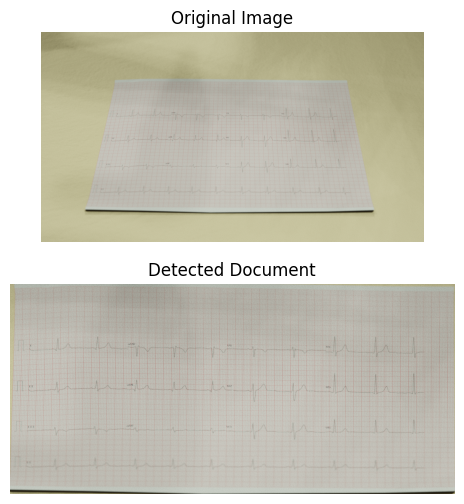

In [70]:
# Visualize the result

fig, ax = plt.subplots(2, 1, figsize = (12, 6))

# Original Image
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")

# Processed Image (Detected Document)
ax[1].imshow(output_image)
ax[1].set_title("Detected Document")
ax[1].axis("off")
plt.show()

(-0.5, 1023.5, 1023.5, -0.5)

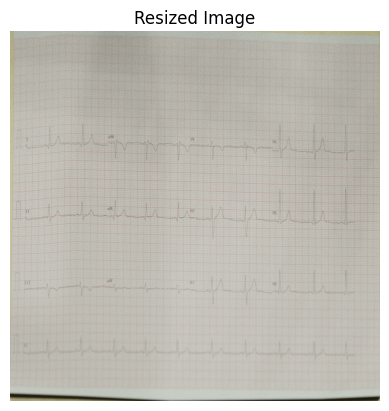

In [71]:
# Resize final image; are we getting aliasing?

fig, ax = plt.subplots()
ax.imshow(resized_image_1024)
ax.set_title("Resized Image")
ax.axis('off')

(-0.5, 511.5, 511.5, -0.5)

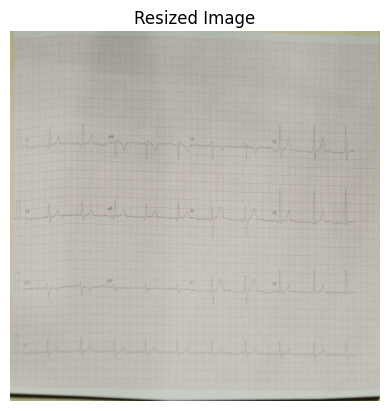

In [72]:
# Resize final image; are we getting aliasing?

fig, ax = plt.subplots()
ax.imshow(resized_image_512)
ax.set_title("Resized Image")
ax.axis('off')

(-0.5, 223.5, 223.5, -0.5)

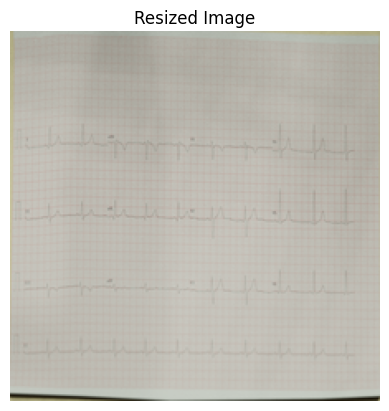

In [73]:
# Resize final image; are we getting aliasing?

fig, ax = plt.subplots()
ax.imshow(resized_image_224)
ax.set_title("Resized Image")
ax.axis('off')